In [157]:
from pybaseball import statcast_single_game, playerid_reverse_lookup
import matplotlib.pyplot as plt
import statsapi as MLB_API
import pandas as pd

## Get Team and Game Info

In [158]:
print("lookup team")
team = MLB_API.lookup_team("dodgers")
last_game_id = MLB_API.last_game(team[0]['id'])
game_info:pd.DataFrame = statcast_single_game(last_game_id)
if not game_info.empty:
    print("got game👍")
else:
    print("get game failed :(")
    raise RuntimeError("failed to get game")

lookup team
got game👍


c:\Python313\Lib\site-packages\pybaseball\datahelpers\postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)


## Game Info

In [159]:
keys = game_info.keys()

with open('game_info_keys.txt', 'w') as f:
    for key in keys:
        f.write(f"{key}\n")

# Write selected columns to CSV (requested columns)
columns_to_write = [
    'pitch_type', 'release_speed', 'player_name', 'pitcher', 'p_throws', 'balls', 'strikes', 'inning',
    'inning_topbot', 'launch_angle', 'lauch_speed', 'effective_speed', 'iso_value', 'woba_value',
    'estimated_woba_using_speedangle', 'estimated_ba_using_speedangle', 'estimated_slg_using_speedangle',
    'delta_pitcher_run_exp', 'hyper_speed', 'events', 'n_priorpa_thisgame_player_at_bat', 'zone',
]
# Keep only columns that actually exist in the DataFrame
cols_present = [c for c in columns_to_write if c in game_info.columns]
# If the user wrote 'lauch_speed' but the DataFrame has 'launch_speed', prefer the correct name
if 'lauch_speed' in columns_to_write and 'lauch_speed' not in cols_present and 'launch_speed' in game_info.columns:
    # insert launch_speed where lauch_speed was requested
    insert_pos = columns_to_write.index('lauch_speed') if 'lauch_speed' in columns_to_write else len(cols_present)
    cols_present.insert(min(insert_pos, len(cols_present)), 'launch_speed')
# Deduplicate while preserving order
seen = set()
cols_present = [c for c in cols_present if not (c in seen or seen.add(c))]
if cols_present:
    game_info.loc[:, cols_present].to_csv('game_info_selected.csv', index=False, encoding='utf-8')
    print(f'Wrote {len(cols_present)} columns to game_info_selected.csv')
else:
    print('No requested columns found in game_info; CSV not written.')
        
home_team = game_info.iloc[0]['home_team']
away_team = game_info.iloc[0]['away_team']

print(f"Game Date: {game_info.iloc[0]['game_date']}")
print(f"{away_team} @ {home_team}")
print(f"{game_info['post_away_score'].max()} - {game_info['post_home_score'].max()}")
if not game_info.iloc[0]['inning'] == 9:
    print(f"Extra innings - ({game_info.iloc[0]['inning']})")

Wrote 22 columns to game_info_selected.csv
Game Date: 2026-04-13 00:00:00
NYM @ LAD
0 - 4


## Batter Info

In [160]:
batters = game_info['batter'].unique().tolist()
names = playerid_reverse_lookup(batters, key_type='mlbam')
if not names.empty:
    batters_list = list(zip(names['key_mlbam'], names['name_first'], names['name_last']))
else:
    batters_list = []

batter_info = []
for batter in batters_list:
    subset = game_info[game_info['batter'] == batter[0]]
    woba = float(round(subset['estimated_woba_using_speedangle'].mean(), 3)) if not subset['estimated_woba_using_speedangle'].isna().all() else 0.0
    xslg = float(round(subset['estimated_slg_using_speedangle'].mean(), 3)) if not subset['estimated_slg_using_speedangle'].isna().all() else 0.0
    xba = float(round(subset['estimated_ba_using_speedangle'].mean(), 3)) if not subset['estimated_ba_using_speedangle'].isna().all() else 0.0

    b_data = {
        'id': batter[0],
        'first_name': batter[1].capitalize(),
        'last_name': batter[2].capitalize(),
        'total_estimated_woba': float(round(subset['estimated_woba_using_speedangle'].sum(), 3)),
        'total_estimated_slg': float(round(subset['estimated_slg_using_speedangle'].sum(), 3)),
        'total_wops': float(round(subset['estimated_woba_using_speedangle'].sum(), 3)) + float(round(subset['estimated_slg_using_speedangle'].sum(), 3)),
        'home_team': subset['inning_topbot'].iloc[0] == 'Bot' if not subset.empty else False,
        'woba': woba,
        'xslg': xslg,
        'xba': xba,
        'wops': round(woba + xslg, 3)
    }
    batter_info.append(b_data)

print(f"Total Unique Batters: {len(batters_list)}")
for b in batter_info:
    print(f"---{b['last_name']}, {b['first_name']}---")
    print(f"Team: {'Home' if b['home_team'] else 'Away'}")
    print(f"wOBA: {b['woba']} | xSLG: {b['xslg']} | xBA: {b['xba']}")


Total Unique Batters: 18
---Polanco, Jorge---
Team: Away
wOBA: 0.352 | xSLG: 0.581 | xBA: 0.256
---Vientos, Mark---
Team: Away
wOBA: 0.199 | xSLG: 0.368 | xBA: 0.32
---Ohtani, Shohei---
Team: Home
wOBA: 0.249 | xSLG: 0.214 | xBA: 0.163
---Freeman, Freddie---
Team: Home
wOBA: 0.475 | xSLG: 0.817 | xBA: 0.647
---Rojas, Miguel---
Team: Home
wOBA: 0.456 | xSLG: 0.779 | xBA: 0.624
---Muncy, Max---
Team: Home
wOBA: 0.0 | xSLG: 0.0 | xBA: 0.0
---Pham, Tommy---
Team: Away
wOBA: 0.313 | xSLG: 0.559 | xBA: 0.514
---Álvarez, Francisco---
Team: Away
wOBA: 0.319 | xSLG: 0.398 | xBA: 0.342
---Pages, Andy---
Team: Home
wOBA: 0.283 | xSLG: 0.853 | xBA: 0.476
---Espinal, Santiago---
Team: Home
wOBA: 0.201 | xSLG: 0.32 | xBA: 0.296
---Taylor, Tyrone---
Team: Away
wOBA: 0.234 | xSLG: 0.278 | xBA: 0.25
---Lindor, Francisco---
Team: Away
wOBA: 0.194 | xSLG: 0.233 | xBA: 0.207
---Semien, Marcus---
Team: Away
wOBA: 0.568 | xSLG: 0.843 | xBA: 0.489
---Robert, Luis---
Team: Away
wOBA: 0.197 | xSLG: 0.229 | xBA

## Team Splits and Game Predictions

## Pitcher Expected Performance

In [161]:
pitchers = game_info['pitcher'].unique().tolist()
names_p = playerid_reverse_lookup(pitchers, key_type='mlbam')
if not names_p.empty:
    pitchers_list = list(zip(names_p['key_mlbam'], names_p['name_first'], names_p['name_last']))
else:
    pitchers_list = []

pitcher_info = []
print("\n--- Pitcher Breakdown (Expected Allowed) ---")
for p in pitchers_list:
    subset = game_info[game_info['pitcher'] == p[0]]
    xwoba_against = float(round(subset['estimated_woba_using_speedangle'].mean(), 3)) if not subset['estimated_woba_using_speedangle'].isna().all() else 0.0
    xslg_against = float(round(subset['estimated_slg_using_speedangle'].mean(), 3)) if not subset['estimated_slg_using_speedangle'].isna().all() else 0.0
    xba_against = float(round(subset['estimated_ba_using_speedangle'].mean(), 3)) if not subset['estimated_ba_using_speedangle'].isna().all() else 0.0
    pitcher_is_home = subset['inning_topbot'].iloc[0] == 'Top' if not subset.empty else False

    p_data = {
        'id': p[0],
        'first_name': p[1].capitalize(),
        'last_name': p[2].capitalize(),
        'xwoba_against': xwoba_against,
        'xslg_against': xslg_against,
        'xba_against': xba_against,
        'home_team': pitcher_is_home
    }
    pitcher_info.append(p_data)
    print(f"{p_data['last_name']}, {p_data['first_name']} ({'Home' if pitcher_is_home else 'Away'}) -> xwOBA: {xwoba_against:.3f} | xSLG: {xslg_against:.3f} | xBA: {xba_against:.3f}")



--- Pitcher Breakdown (Expected Allowed) ---
Gerber, Joey (Away) -> xwOBA: 0.264 | xSLG: 0.724 | xBA: 0.565
Wrobleski, Justin (Home) -> xwOBA: 0.303 | xSLG: 0.438 | xBA: 0.322
Kimbrel, Craig (Away) -> xwOBA: 0.429 | xSLG: 0.538 | xBA: 0.446
Peterson, David (Away) -> xwOBA: 0.362 | xSLG: 0.553 | xBA: 0.421
Scott, Tanner (Home) -> xwOBA: 0.401 | xSLG: 0.484 | xBA: 0.436


## Batted Ball Profiles

In [162]:
import numpy as np
print("\n--- Batted Ball Profiles (Team) ---")
game_info_hit = game_info.dropna(subset=['launch_angle', 'launch_speed']).copy()
conditions = [
    (game_info_hit['launch_angle'] < 10),
    (game_info_hit['launch_angle'] >= 10) & (game_info_hit['launch_angle'] <= 25),
    (game_info_hit['launch_angle'] > 25) & (game_info_hit['launch_angle'] <= 50),
    (game_info_hit['launch_angle'] > 50)
]
choices = ['Groundball', 'Line Drive', 'Flyball', 'Pop-Up']
game_info_hit['bb_type'] = np.select(conditions, choices, default='Unknown')
game_info_hit['is_hard_hit'] = game_info_hit['launch_speed'] >= 95

for topbot in ['Top', 'Bot']:
    team = home_team if topbot == 'Bot' else away_team
    subset = game_info_hit[game_info_hit['inning_topbot'] == topbot]
    if subset.empty: continue
    hard_hit_pct = subset['is_hard_hit'].mean() * 100
    bb_dist = subset['bb_type'].value_counts(normalize=True) * 100
    print(f"\n[{team}] Batted Ball Profile:")
    print(f"Hard Hit %: {hard_hit_pct:.1f}%")
    for bb, pct in bb_dist.items():
        print(f"  {bb}: {pct:.1f}%")



--- Batted Ball Profiles (Team) ---

[NYM] Batted Ball Profile:
Hard Hit %: 29.8%
  Groundball: 44.7%
  Flyball: 31.9%
  Line Drive: 12.8%
  Pop-Up: 10.6%

[LAD] Batted Ball Profile:
Hard Hit %: 34.8%
  Flyball: 28.3%
  Groundball: 28.3%
  Line Drive: 26.1%
  Pop-Up: 17.4%


In [163]:
home_info = [b for b in batter_info if b['home_team']]
away_info = [b for b in batter_info if not b['home_team']]

def print_team_info(team_info:list, home_away:bool) -> None:
    print(f'-----{home_team if home_away else away_team} Team Info (Offense)-----')
    print(f"Expected runs (xwOBA proxy): {sum(b['total_estimated_woba'] for b in team_info):.2f}")
    print(f"Team xwOBA: {round(sum(b['woba'] for b in team_info) / len(team_info) if team_info else 0, 3)}")
    print(f"Team xBA: {round(sum(b['xba'] for b in team_info) / len(team_info) if team_info else 0, 3)}")
    print('\n')

print_team_info(home_info, True)
print_team_info(away_info, False)

print('-----Game Analysis (Luck-Independent Win Prob)-----')
home_xruns = sum(b['total_estimated_woba'] for b in home_info)
away_xruns = sum(b['total_estimated_woba'] for b in away_info)

pyth_exp = 1.83
home_dtwom = (home_xruns**pyth_exp) / (home_xruns**pyth_exp + away_xruns**pyth_exp) * 100 if (home_xruns + away_xruns) > 0 else 50
away_dtwom = 100 - home_dtwom

print(f'{home_team} Deserve-to-Win-O-Meter: {round(home_dtwom, 2)}%')
print(f'{away_team} Deserve-to-Win-O-Meter: {round(away_dtwom, 2)}%')
home_bat_dtwom = home_dtwom
away_bat_dtwom = away_dtwom
home_pitch_dtwom = home_dtwom
away_pitch_dtwom = away_dtwom


-----LAD Team Info (Offense)-----
Expected runs (xwOBA proxy): 12.72
Team xwOBA: 0.347
Team xBA: 0.419


-----NYM Team Info (Offense)-----
Expected runs (xwOBA proxy): 8.79
Team xwOBA: 0.318
Team xBA: 0.346


-----Game Analysis (Luck-Independent Win Prob)-----
LAD Deserve-to-Win-O-Meter: 66.3%
NYM Deserve-to-Win-O-Meter: 33.7%


## Visualizations

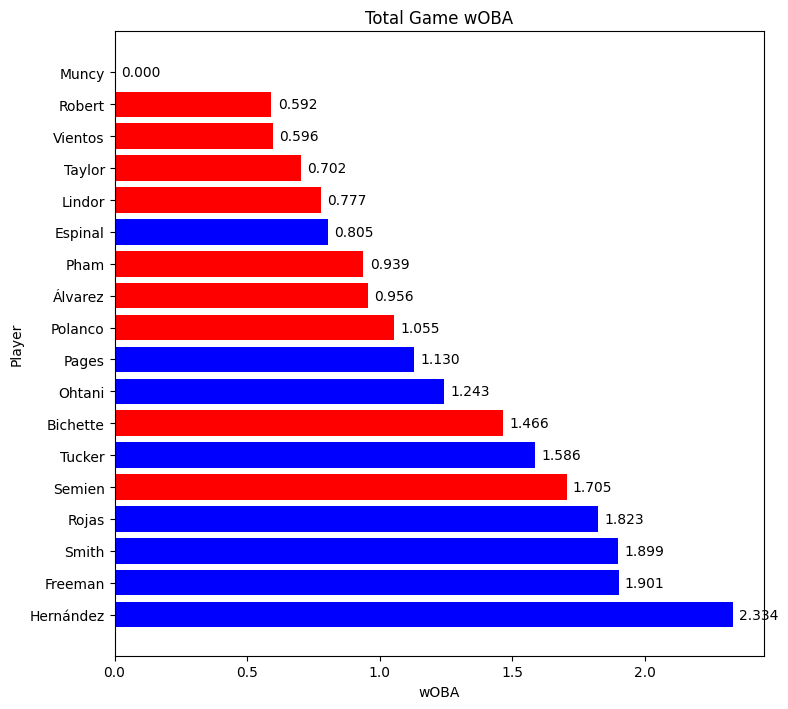

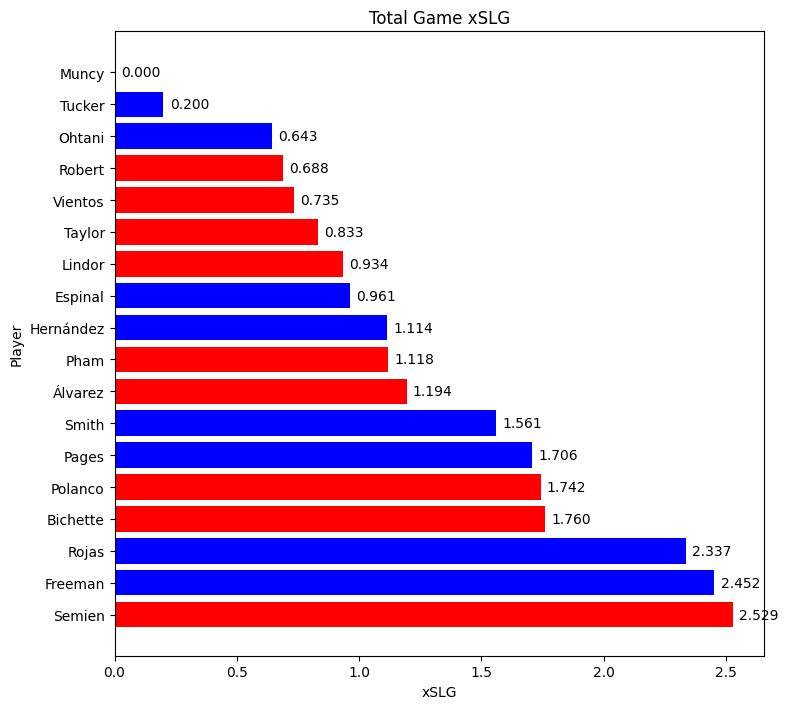

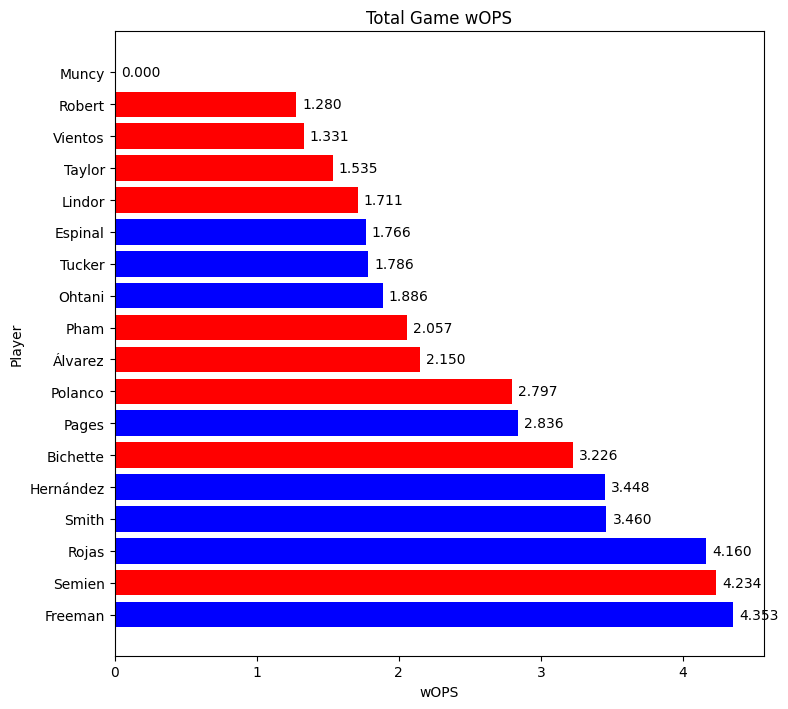

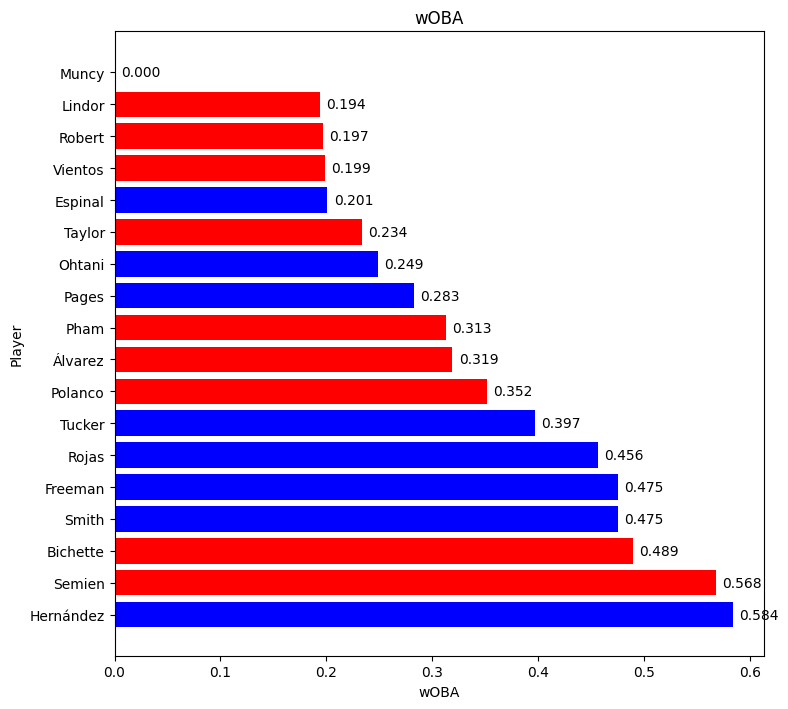

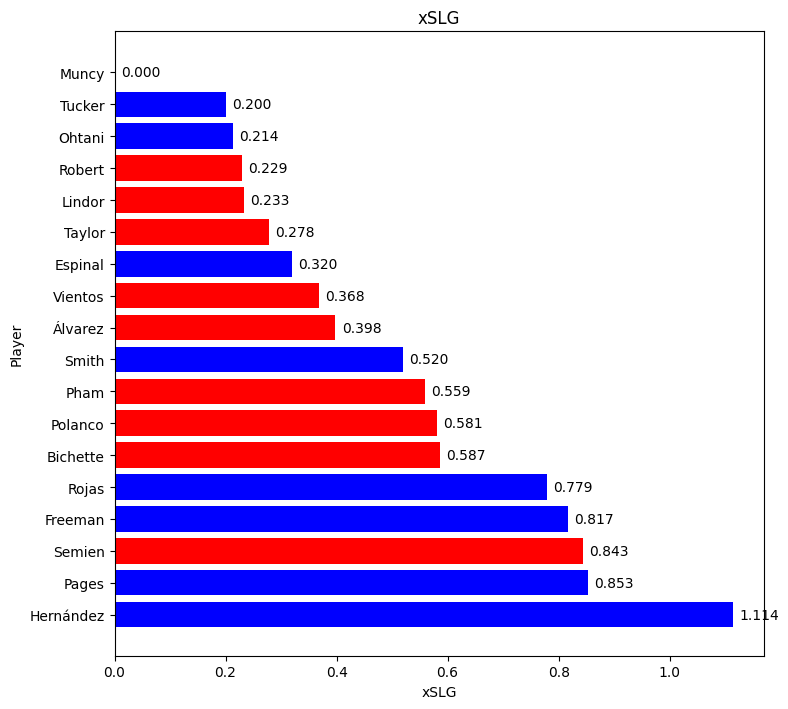

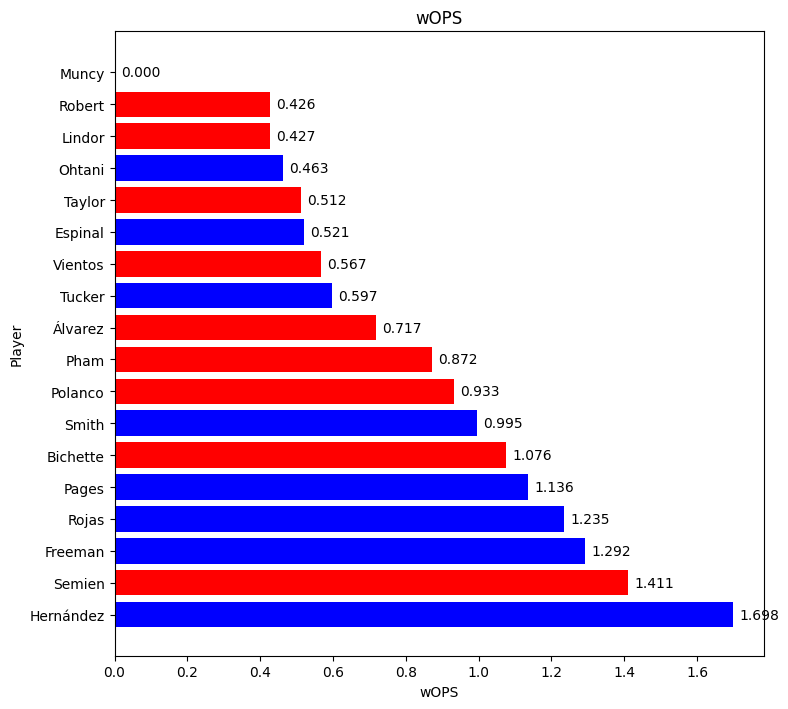

In [164]:
#Totals Graphs

#wOBA graph
sorted_batters = sorted(batter_info, key=lambda b: b['total_estimated_woba'])
categories = [b['last_name'] for b in sorted_batters]
values = [b['total_estimated_woba'] for b in sorted_batters]
colors = ['blue' if b['home_team'] else 'red' for b in sorted_batters]

plt.figure(figsize=(8, max(4, len(categories) * 0.4)))
bars = plt.barh(categories, values, color=colors)
plt.xlabel('wOBA')
plt.ylabel('Player')
plt.title('Total Game wOBA')
plt.gca().invert_yaxis()
for bar, v in zip(bars, values):
    plt.text(bar.get_width() + (max(values) if values else 0) * 0.01, bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

#xSLG graph
sorted_batters = sorted(batter_info, key=lambda b: b['total_estimated_slg'])
categories = [b['last_name'] for b in sorted_batters]
values = [b['total_estimated_slg'] for b in sorted_batters]
colors = ['blue' if b['home_team'] else 'red' for b in sorted_batters]

plt.figure(figsize=(8, max(4, len(categories) * 0.4)))
bars = plt.barh(categories, values, color=colors)
plt.xlabel('xSLG')
plt.ylabel('Player')
plt.title('Total Game xSLG')
plt.gca().invert_yaxis()
for bar, v in zip(bars, values):
    plt.text(bar.get_width() + (max(values) if values else 0) * 0.01, bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

#wOPS graph
sorted_batters = sorted(batter_info, key=lambda b: b['total_wops'])
categories = [b['last_name'] for b in sorted_batters]
values = [b['total_wops'] for b in sorted_batters]
colors = ['blue' if b['home_team'] else 'red' for b in sorted_batters]
plt.figure(figsize=(8, max(4, len(categories) * 0.4)))
bars = plt.barh(categories, values, color=colors)
plt.xlabel('wOPS')
plt.ylabel('Player')
plt.title('Total Game wOPS')
plt.gca().invert_yaxis()
for bar, v in zip(bars, values):
    plt.text(bar.get_width() + (max(values) if values else 0) * 0.01, bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

#Graphs for Averages

#wOBA graph
sorted_batters = sorted(batter_info, key=lambda b: b['woba'])
categories = [b['last_name'] for b in sorted_batters]
values = [b['woba'] for b in sorted_batters]
colors = ['blue' if b['home_team'] else 'red' for b in sorted_batters]

plt.figure(figsize=(8, max(4, len(categories) * 0.4)))
bars = plt.barh(categories, values, color=colors)
plt.xlabel('wOBA')
plt.ylabel('Player')
plt.title('wOBA')
plt.gca().invert_yaxis()
for bar, v in zip(bars, values):
    plt.text(bar.get_width() + (max(values) if values else 0) * 0.01, bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

#xSLG graph
sorted_batters = sorted(batter_info, key=lambda b: b['xslg'])
categories = [b['last_name'] for b in sorted_batters]
values = [b['xslg'] for b in sorted_batters]
colors = ['blue' if b['home_team'] else 'red' for b in sorted_batters]

plt.figure(figsize=(8, max(4, len(categories) * 0.4)))
bars = plt.barh(categories, values, color=colors)
plt.xlabel('xSLG')
plt.ylabel('Player')
plt.title('xSLG')
plt.gca().invert_yaxis()
for bar, v in zip(bars, values):
    plt.text(bar.get_width() + (max(values) if values else 0) * 0.01, bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

#wOPS graph
sorted_batters = sorted(batter_info, key=lambda b: b['wops'])
categories = [b['last_name'] for b in sorted_batters]
values = [b['wops'] for b in sorted_batters]
colors = ['blue' if b['home_team'] else 'red' for b in sorted_batters]
plt.figure(figsize=(8, max(4, len(categories) * 0.4)))
bars = plt.barh(categories, values, color=colors)
plt.xlabel('wOPS')
plt.ylabel('Player')
plt.title('wOPS')
plt.gca().invert_yaxis()
for bar, v in zip(bars, values):
    plt.text(bar.get_width() + (max(values) if values else 0) * 0.01, bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

## Pitching Above Expected

In [165]:
#take all the game data
# seperate into home pitching (top of the inning)

pitchers = game_info['pitcher'].unique().tolist()

home_pitchers:list = game_info.loc[game_info['inning_topbot'] == 'Top', 'pitcher'].unique().tolist()
away_pitchers:list = game_info.loc[game_info['inning_topbot'] == 'Bot', 'pitcher'].unique().tolist()

hp_df:pd.DataFrame = playerid_reverse_lookup(home_pitchers, key_type='mlbam')
ap_df:pd.DataFrame = playerid_reverse_lookup(away_pitchers, key_type='mlbam')

hp_tuples:list[tuple[int, str, str]] = list(zip(hp_df['key_mlbam'].tolist(), hp_df['name_last'].tolist(), hp_df['name_first'].tolist()))
ap_tuples:list[tuple[int, str, str]] = list(zip(ap_df['key_mlbam'].tolist(), ap_df['name_last'].tolist(), ap_df['name_first'].tolist()))

print(f'{home_team} # of pitchers: {len(home_pitchers)}')
print(f'{away_team} # of pitchers: {len(away_pitchers)}')

home_pitching_exp_runs:float = -1 * round(game_info.loc[game_info['inning_topbot'] == 'Top', 'delta_pitcher_run_exp'].sum(), 3)
away_pitching_exp_runs:float = -1 * round(game_info.loc[game_info['inning_topbot'] == 'Bot', 'delta_pitcher_run_exp'].sum(), 3)

print(f'{home_team} Pitching expected runs: {home_pitching_exp_runs}')
print(f'{away_team} Pitching expected runs: {away_pitching_exp_runs}')

print("Individual Home Pitchers Impact")
for p in hp_tuples:
    print(f'{p[2].capitalize()} {p[1].capitalize()} - {-1 * round(game_info.loc[game_info['pitcher'] == p[0], 'delta_pitcher_run_exp'].sum(), 3)} expected runs given up')

print("Individual Away Pitchers Impact")
for p in ap_tuples:
    print(f'{p[2].capitalize()} {p[1].capitalize()} - {-1 * round(game_info.loc[game_info['pitcher'] == p[0], 'delta_pitcher_run_exp'].sum(), 3)} expected runs given up')

print("Pitching above expected:")
home_pitch_above_exp = round(home_pitching_exp_runs - game_info['post_away_score'].max(), 3)
away_pitch_above_exp = round(away_pitching_exp_runs - game_info['post_home_score'].max(), 3)
print(f'{home_team}: {home_pitch_above_exp}')
print(f'{away_team}: {away_pitch_above_exp}')

home_pitch_dtwom = round((home_pitch_above_exp / (home_pitch_above_exp + away_pitch_above_exp) * 100), 2)
away_pitch_dtwom = round((away_pitch_above_exp / (home_pitch_above_exp + away_pitch_above_exp) * 100), 2)
print(f"{home_team} deserve to win (pitching): {home_pitch_dtwom}%")
print(f"{away_team} deserve to win (pitching): {away_pitch_dtwom}%")

LAD # of pitchers: 2
NYM # of pitchers: 3
LAD Pitching expected runs: -5.426
NYM Pitching expected runs: 1.972
Individual Home Pitchers Impact
Justin Wrobleski - -5.303 expected runs given up
Tanner Scott - -0.123 expected runs given up
Individual Away Pitchers Impact
Joey Gerber - 0.068 expected runs given up
Craig Kimbrel - -0.101 expected runs given up
David Peterson - 2.005 expected runs given up
Pitching above expected:
LAD: -5.426
NYM: -2.028
LAD deserve to win (pitching): 72.79%
NYM deserve to win (pitching): 27.21%


## Deserve-to-Win-O-Meter

In [166]:
home_dtwom = round((home_bat_dtwom + home_pitch_dtwom) / 2, 2)
away_dtwom = round((away_bat_dtwom + away_pitch_dtwom) / 2, 2)
print(f'{home_team} Deserve-to-Win-O-Meter: {home_dtwom}%')
print(f'{away_team} Deserve-to-Win-O-Meter: {away_dtwom}%')

print(f'{home_team if away_dtwom < 50 else away_team} deserved to win that game')

LAD Deserve-to-Win-O-Meter: 69.55%
NYM Deserve-to-Win-O-Meter: 30.45%
LAD deserved to win that game


## Advanced Visualizations (Inning Flow)

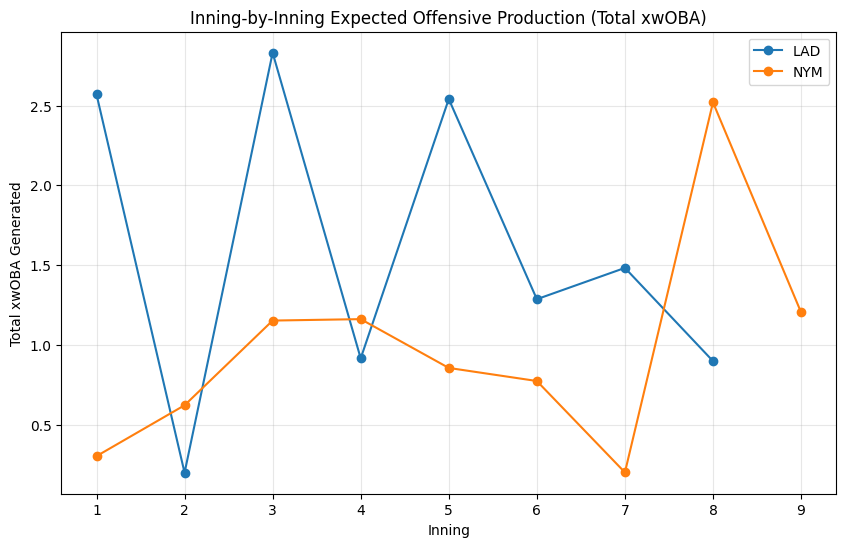

In [167]:
import matplotlib.pyplot as plt

inning_flow = game_info.groupby(['inning', 'inning_topbot'])['estimated_woba_using_speedangle'].sum().reset_index()
inning_flow['team'] = inning_flow['inning_topbot'].apply(lambda x: home_team if x == 'Bot' else away_team)

plt.figure(figsize=(10, 6))
for team in [home_team, away_team]:
    team_data = inning_flow[inning_flow['team'] == team]
    plt.plot(team_data['inning'], team_data['estimated_woba_using_speedangle'], marker='o', label=team)

plt.title('Inning-by-Inning Expected Offensive Production (Total xwOBA)')
plt.xlabel('Inning')
plt.ylabel('Total xwOBA Generated')
plt.xticks(range(1, inning_flow['inning'].max() + 1))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Export HTML Report

In [186]:
import base64
from io import BytesIO

fig = plt.figure(figsize=(10, 6))
for team in [home_team, away_team]:
    team_data = inning_flow[inning_flow['team'] == team]
    plt.plot(team_data['inning'], team_data['estimated_woba_using_speedangle'], marker='o', label=team)
plt.title('Inning-by-Inning Expected Offensive Production (Total xwOBA)')
plt.xlabel('Inning')
plt.ylabel('Total xwOBA Generated')
plt.xticks(range(1, inning_flow['inning'].max() + 1))
plt.grid(True, alpha=0.3)
plt.legend()
buf = BytesIO()
plt.savefig(buf, format='png', bbox_inches='tight')
plt.close(fig)
image_base64 = base64.b64encode(buf.getvalue()).decode('utf-8')

def get_b64_barh(key, title, xlabel):
    sb = sorted(batter_info, key=lambda b: b[key])
    categories = [b['last_name'] for b in sb]
    values = [b[key] for b in sb]
    colors = ['blue' if b['home_team'] else 'red' for b in sb]
    fig = plt.figure(figsize=(8, max(4, len(categories) * 0.4)))
    bars = plt.barh(categories, values, color=colors)
    plt.xlabel(xlabel)
    plt.ylabel('Player')
    plt.title(title)
    plt.gca().invert_yaxis()
    for bar, v in zip(bars, values):
        plt.text(bar.get_width() + (max(values) if values else 0) * 0.01, bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center')
    plt.tight_layout()
    buf = BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    plt.close(fig)
    return base64.b64encode(buf.getvalue()).decode('utf-8')

b64_total_woba = get_b64_barh('total_estimated_woba', 'Total Game wOBA', 'wOBA')
b64_total_xslg = get_b64_barh('total_estimated_slg', 'Total Game xSLG', 'xSLG')
b64_total_wops = get_b64_barh('total_wops', 'Total Game wOPS', 'wOPS')
b64_avg_woba = get_b64_barh('woba', 'wOBA', 'wOBA')
b64_avg_xslg = get_b64_barh('xslg', 'xSLG', 'xSLG')
b64_avg_wops = get_b64_barh('wops', 'wOPS', 'wOPS')

# Batted ball
home_bb_html = ""
away_bb_html = ""

for topbot in ['Top', 'Bot']:
    team = home_team if topbot == 'Bot' else away_team
    subset = game_info_hit[game_info_hit['inning_topbot'] == topbot]
    if not subset.empty:
        hard_hit_pct = subset['is_hard_hit'].mean() * 100
        bb_dist = subset['bb_type'].value_counts(normalize=True) * 100
        bb_h = f"<h3>Batted Ball Profile</h3><ul>"
        bb_h += f"<li>Hard Hit %: {hard_hit_pct:.1f}%</li>"
        for bb, pct in bb_dist.items():
            bb_h += f"<li>{bb}: {pct:.1f}%</li>"
        bb_h += "</ul>"
        if team == home_team:
            home_bb_html = bb_h
        else:
            away_bb_html = bb_h

# Team info summaries
home_team_xwoba = sum(b['woba'] for b in home_info) / len(home_info) if home_info else 0
home_team_xba = sum(b['xba'] for b in home_info) / len(home_info) if home_info else 0
away_team_xwoba = sum(b['woba'] for b in away_info) / len(away_info) if away_info else 0
away_team_xba = sum(b['xba'] for b in away_info) / len(away_info) if away_info else 0

away_pitch_html = ""
home_pitch_html = ""
for p in pitcher_info:
    row = f"<tr><td>{p['last_name']}, {p['first_name']}</td><td>{p['xwoba_against']:.3f}</td><td>{p['xslg_against']:.3f}</td><td>{p['xba_against']:.3f}</td></tr>\n"
    if p['home_team']:
        home_pitch_html += row
    else:
        away_pitch_html += row

away_bat_html = ""
home_bat_html = ""
s_home = sorted(home_info, key=lambda x: x['total_wops'], reverse=True)
s_away = sorted(away_info, key=lambda x: x['total_wops'], reverse=True)

for b in s_home:
    home_bat_html += f"<tr><td>{b['last_name']}, {b['first_name']}</td><td>{b['woba']:.3f}</td><td>{b['xslg']:.3f}</td><td>{b['wops']:.3f}</td><td>{b['xba']:.3f}</td></tr>\n"
for b in s_away:
    away_bat_html += f"<tr><td>{b['last_name']}, {b['first_name']}</td><td>{b['woba']:.3f}</td><td>{b['xslg']:.3f}</td><td>{b['wops']:.3f}</td><td>{b['xba']:.3f}</td></tr>\n"

home_pitch_impact_html = ""
away_pitch_impact_html = ""
for p in hp_tuples:
    exp_runs = -1 * round(game_info.loc[game_info['pitcher'] == p[0], 'delta_pitcher_run_exp'].sum(), 3)
    home_pitch_impact_html += f"<tr><td>{p[2].capitalize()} {p[1].capitalize()}</td><td>{exp_runs:.3f}</td></tr>\n"
for p in ap_tuples:
    exp_runs = -1 * round(game_info.loc[game_info['pitcher'] == p[0], 'delta_pitcher_run_exp'].sum(), 3)
    away_pitch_impact_html += f"<tr><td>{p[2].capitalize()} {p[1].capitalize()}</td><td>{exp_runs:.3f}</td></tr>\n"

game_date = str(game_info.iloc[0]['game_date'])
home_score = int(game_info['post_home_score'].max())
away_score = int(game_info['post_away_score'].max())
max_inning = int(game_info['inning'].max()) if 'inning' in game_info.columns else 9
extra_innings_text = f"<li>Extra innings played: {max_inning}</li>" if max_inning > 9 else ""
winner_by_dtwom = home_team if away_dtwom < 50 else away_team
home_pitch_count = len(home_pitchers)
away_pitch_count = len(away_pitchers)
total_unique_batters = len(batters_list)
total_unique_pitchers = len(pitchers_list)

html_content = f'''<!DOCTYPE html>
<html>
<head>
    <title>{away_team} @ {home_team} - Post-Game Analysis</title>
    <meta charset="utf-8">
    <style>
        body {{ font-family: 'Inter', sans-serif; margin: 40px; background-color: #f8f9fa; color: #333; }}
        h1, h2, h3 {{ color: #1a1a1a; }}
        .header {{ text-align: center; margin-bottom: 40px; }}
        .dtwom-box {{ background-color: #fff; padding: 20px; border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); text-align: center; margin-bottom: 40px; }}
        .dtwom-score {{ font-size: 1.5em; font-weight: bold; color: #0056b3; margin: 6px 0; }}
        table {{ width: 100%; border-collapse: collapse; margin-bottom: 30px; background-color: #fff; font-size: 0.9em; }}
        th, td {{ padding: 10px; text-align: left; border-bottom: 1px solid #ddd; }}
        th {{ background-color: #0056b3; color: white; }}
        tr:nth-child(even) {{ background-color: #f9f9f9; }}
        tr:hover {{ background-color: #f1f1f1; }}
        .img-container {{ text-align: center; margin-bottom: 40px; }}
        .section {{ background-color: #fff; padding: 20px; border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); margin-bottom: 40px; }}
        .flex-container {{ display: flex; justify-content: space-between; gap: 20px; flex-wrap: wrap; }}
        .flex-child {{ flex: 1; min-width: 30%; }}
        ul {{ line-height: 1.6; }}
        .table-wrap {{ overflow-x: auto; max-height: 460px; overflow-y: auto; border: 1px solid #ddd; border-radius: 8px; }}
        .key-list {{ columns: 2; column-gap: 24px; }}
        .note {{ color: #444; font-size: 0.95em; }}
        @media (max-width: 900px) {{
            body {{ margin: 16px; }}
            .flex-child {{ min-width: 100%; }}
            .key-list {{ columns: 1; }}
        }}
    </style>
</head>
<body>
    <div class="header">
        <h1>Post-Game Expected Performance Report</h1>
        <h2>{away_team} @ {home_team}</h2>
        <p><strong>Date:</strong> {game_date}</p>
        <p><strong>Final score:</strong> {away_team} {away_score} - {home_team} {home_score}</p>
    </div>

    <div class="dtwom-box">
        <h2>Deserve-To-Win O-Meter</h2>
        <p class="dtwom-score">Offense: {away_team} {away_bat_dtwom:.2f}% | {home_team} {home_bat_dtwom:.2f}%</p>
        <p class="dtwom-score">Pitching: {away_team} {away_pitch_dtwom:.2f}% | {home_team} {home_pitch_dtwom:.2f}%</p>
        <p class="dtwom-score">Overall: {away_team} {away_dtwom:.2f}% | {home_team} {home_dtwom:.2f}%</p>
        <p><strong>Verdict:</strong> {winner_by_dtwom} deserved to win this game.</p>
    </div>

    <div class="section flex-container">
        <div class="flex-child">
            <h2>{away_team} Team Overview</h2>
            <ul>
                <li>Expected runs (xwOBA proxy): {away_xruns:.2f}</li>
                <li>Team xwOBA: {away_team_xwoba:.3f}</li>
                <li>Team xBA: {away_team_xba:.3f}</li>
                <li>Pitchers used: {away_pitch_count}</li>
            </ul>
            {away_bb_html}
        </div>
        <div class="flex-child">
            <h2>{home_team} Team Overview</h2>
            <ul>
                <li>Expected runs (xwOBA proxy): {home_xruns:.2f}</li>
                <li>Team xwOBA: {home_team_xwoba:.3f}</li>
                <li>Team xBA: {home_team_xba:.3f}</li>
                <li>Pitchers used: {home_pitch_count}</li>
            </ul>
            {home_bb_html}
        </div>
    </div>

    <div class="section flex-container">
        <div class="flex-child">
            <h2>{away_team} Pitching Above Expected</h2>
            <ul>
                <li>Pitching expected runs: {away_pitching_exp_runs:.3f}</li>
                <li>Pitching above expected: {away_pitch_above_exp:.3f}</li>
            </ul>
            <h3>Individual Pitching Impact</h3>
            <table>
                <tr><th>Pitcher</th><th>Expected runs given up</th></tr>
                {away_pitch_impact_html}
            </table>
        </div>
        <div class="flex-child">
            <h2>{home_team} Pitching Above Expected</h2>
            <ul>
                <li>Pitching expected runs: {home_pitching_exp_runs:.3f}</li>
                <li>Pitching above expected: {home_pitch_above_exp:.3f}</li>
            </ul>
            <h3>Individual Pitching Impact</h3>
            <table>
                <tr><th>Pitcher</th><th>Expected runs given up</th></tr>
                {home_pitch_impact_html}
            </table>
        </div>
    </div>

    <div class="section">
        <h2>Player Comparisons (Totals)</h2>
        <div class="flex-container">
            <div class="flex-child img-container"><img src="data:image/png;base64,{b64_total_woba}" alt="Total wOBA" style="width:100%; height:auto;"></div>
            <div class="flex-child img-container"><img src="data:image/png;base64,{b64_total_xslg}" alt="Total xSLG" style="width:100%; height:auto;"></div>
            <div class="flex-child img-container"><img src="data:image/png;base64,{b64_total_wops}" alt="Total wOPS" style="width:100%; height:auto;"></div>
        </div>
        <h2>Player Comparisons (Averages)</h2>
        <div class="flex-container">
            <div class="flex-child img-container"><img src="data:image/png;base64,{b64_avg_woba}" alt="Average wOBA" style="width:100%; height:auto;"></div>
            <div class="flex-child img-container"><img src="data:image/png;base64,{b64_avg_xslg}" alt="Average xSLG" style="width:100%; height:auto;"></div>
            <div class="flex-child img-container"><img src="data:image/png;base64,{b64_avg_wops}" alt="Average wOPS" style="width:100%; height:auto;"></div>
        </div>
    </div>

    <div class="section">
        <h2>Inning-by-Inning Expected Offensive Production</h2>
        <div class="img-container">
            <img src="data:image/png;base64,{image_base64}" alt="Inning Flow Chart" style="max-width:100%; height:auto;">
        </div>
    </div>

    <div class="section flex-container">
        <div class="flex-child">
            <h2>{away_team} Pitching (Allowed Expected)</h2>
            <table>
                <tr><th>Pitcher</th><th>xwOBA</th><th>xSLG</th><th>xBA</th></tr>
                {away_pitch_html}
            </table>
        </div>
        <div class="flex-child">
            <h2>{home_team} Pitching (Allowed Expected)</h2>
            <table>
                <tr><th>Pitcher</th><th>xwOBA</th><th>xSLG</th><th>xBA</th></tr>
                {home_pitch_html}
            </table>
        </div>
    </div>

    <div class="section flex-container">
        <div class="flex-child">
            <h2>{away_team} Expected Offense</h2>
            <table>
                <tr><th>Batter</th><th>xwOBA</th><th>xSLG</th><th>wOPS</th><th>xBA</th></tr>
                {away_bat_html}
            </table>
        </div>
        <div class="flex-child">
            <h2>{home_team} Expected Offense</h2>
            <table>
                <tr><th>Batter</th><th>xwOBA</th><th>xSLG</th><th>wOPS</th><th>xBA</th></tr>
                {home_bat_html}
            </table>
        </div>
    </div>
</body>
</html>
'''

with open('report.html', 'w', encoding='utf-8') as f:
    f.write(html_content)
print('Report saved successfully to report.html!')

Report saved successfully to report.html!
